In [34]:
import pandas as pd
import geopandas as gpd
import numpy as np
from shapely.geometry import box
import matplotlib.pyplot as plt
import os

BASE = "/Users/alexia/Documents/CASA/Dissertation"

census_london = pd.read_csv(os.path.join(BASE, "05_processed/census_london_clean.csv"))
imd_london    = pd.read_csv(os.path.join(BASE, "05_processed/imd_london_clean.csv"))
osev_london   = pd.read_csv(os.path.join(BASE, "05_processed/osev_london_clean.csv"))

lsoa_boundaries = gpd.read_file(os.path.join(BASE, "03_data/demand/spatial/LSOA_2021_EW_BGC_V5.shp")).to_crs(epsg=27700)
london_codes = set(census_london["lsoa_code"])
lsoa_london = lsoa_boundaries[lsoa_boundaries["LSOA21CD"].isin(london_codes)].rename(columns={"LSOA21CD": "lsoa_code"})

print("Reloaded.")
print(f"census_london: {census_london.shape}, imd_london: {imd_london.shape}, lsoa_london: {lsoa_london.shape}")

Reloaded.
census_london: (4994, 4), imd_london: (4994, 10), lsoa_london: (4994, 9)


In [35]:
# Derive Camden's bounding box programmatically (avoids hardcoding approximate coordinates)
camden_lsoa_codes = set(imd_london[imd_london["lad_name"] == "Camden"]["lsoa_code"])
print(f"Camden LSOAs: {len(camden_lsoa_codes)}")

camden_boundary = lsoa_london[lsoa_london["lsoa_code"].isin(camden_lsoa_codes)].copy()
camden_bounds_27700 = camden_boundary.total_bounds  # [minx, miny, maxx, maxy], EPSG:27700

# pyrosm expects bounding_box in WGS84 (EPSG:4326)
camden_bbox_gdf = gpd.GeoDataFrame(geometry=[box(*camden_bounds_27700)], crs="EPSG:27700").to_crs(epsg=4326)
camden_bbox_wgs84 = list(camden_bbox_gdf.total_bounds)

print("Camden bounding box (WGS84, minx/miny/maxx/maxy):", camden_bbox_wgs84)

Camden LSOAs: 130
Camden bounding box (WGS84, minx/miny/maxx/maxy): [np.float64(-0.2150721588408762), np.float64(51.512306601144665), np.float64(-0.1031257195732434), np.float64(51.573681985488534)]


### pyrosm

In [36]:
from pyrosm import OSM

pbf_path = os.path.join(BASE, "03_data/supply/osm/greater-london-latest.osm.pbf")

# Restrict to Camden's bounding box at load time — much faster than parsing all of Greater London
osm = OSM(pbf_path, bounding_box=camden_bbox_wgs84)

# Pull ALL tags for these highway types so we can see exactly what parking-related keys exist —
# extra_attributes lets pyrosm surface specific tag keys as their own columns instead of bundling
# them into a generic 'tags' blob
highway_types = ["residential", "tertiary", "secondary", "unclassified"]

roads_raw = osm.get_data_by_custom_criteria(
    custom_filter={"highway": highway_types},
    filter_type="keep",
    keep_nodes=False,
    keep_ways=True,
    keep_relations=False,
)

print("Shape:", roads_raw.shape)
print("Columns:", roads_raw.columns.tolist())

Shape: (8607, 33)
Columns: ['access', 'bicycle', 'bridge', 'busway', 'cycleway', 'est_width', 'foot', 'highway', 'junction', 'lanes', 'lit', 'maxspeed', 'motorcar', 'motor_vehicle', 'name', 'oneway', 'oneway:bicycle', 'overtaking', 'psv', 'ref', 'service', 'segregated', 'sidewalk', 'smoothness', 'surface', 'tunnel', 'width', 'id', 'timestamp', 'version', 'tags', 'osm_type', 'geometry']


In [37]:
# Check the 'tags' column (pyrosm bundles non-extracted keys here as a dict/JSON string) for any
# parking-related keys actually present in Camden's OSM data
import json

def extract_parking_keys(tags_value):
    if pd.isna(tags_value):
        return []
    try:
        tags_dict = json.loads(tags_value) if isinstance(tags_value, str) else tags_value
        return [k for k in tags_dict.keys() if "parking" in k.lower()]
    except (TypeError, json.JSONDecodeError):
        return []

if "tags" in roads_raw.columns:
    all_parking_keys = roads_raw["tags"].apply(extract_parking_keys)
    found_keys = set(k for keys in all_parking_keys for k in keys)
    print("Parking-related tag keys found in Camden roads data:", found_keys)
    print(f"Ways with at least one parking-related tag: {(all_parking_keys.str.len() > 0).sum()} / {len(roads_raw)}")
else:
    print("No 'tags' column — check roads_raw.columns above for any parking:lane:* columns directly")

Parking-related tag keys found in Camden roads data: {'parking:lane:left:parallel', 'parking:right:taxi', 'parking:condition:right:residents', 'parking:condition:both', 'parking:lane:right', 'parking:left:orientation', 'parking:both:restriction', 'proposed:parking:lane:both', 'parking:left', 'parking:both', 'parking', 'parking:right:zone', 'parking:right', 'parking:lane:left:diagonal', 'parking:condition:right', 'parking:both:markings', 'parking:right:restriction', 'parking:both:restriction:reason', 'parking:left:markings', 'parking:both:zone', 'parking:lane:right:diagonal', 'parking:lane:both:parallel', 'parking:left:restriction:reason', 'parking:lane:both', 'parking:right:markings', 'parking:lane:right:parallel', 'parking:right:zone:conditional', 'parking:lane', 'parking:condition:both:residents', 'parking:left:restriction', 'parking:right:restriction:reason', 'parking:both:orientation', 'parking:right:access', 'parking:right:orientation', 'parking:lane:left', 'parking:both:access'}


In [38]:
# Explore actual values for every parking-orientation-related tagging pattern found in the data —
# don't assume which convention(s) the Camden dataset actually uses; check all of them
def get_tag_value(tags_value, key):
    if pd.isna(tags_value):
        return None
    try:
        tags_dict = json.loads(tags_value) if isinstance(tags_value, str) else tags_value
        return tags_dict.get(key)
    except (TypeError, json.JSONDecodeError):
        return None

patterns_to_check = [
    # Canonical: parking:lane:<side> = orientation
    "parking:lane:both", "parking:lane:left", "parking:lane:right",
    # Bare, no side
    "parking:lane",
    # Alternate convention found in found_keys: parking:<side>:orientation = orientation
    "parking:both:orientation", "parking:left:orientation", "parking:right:orientation",
]

for key in patterns_to_check:
    values = roads_raw["tags"].apply(lambda t: get_tag_value(t, key))
    vc = values.dropna().value_counts()
    if len(vc) > 0:
        print(f"=== {key} ===")
        print(vc.to_string())
        print()

=== parking:lane:both ===
tags
no          29
parallel     6

=== parking:lane:left ===
tags
no          15
parallel     3
diagonal     1

=== parking:lane:right ===
tags
no          17
diagonal     3
parallel     2

=== parking:lane ===
tags
right    1

=== parking:both:orientation ===
tags
parallel         105
perpendicular      1

=== parking:left:orientation ===
tags
parallel    34

=== parking:right:orientation ===
tags
parallel         41
diagonal          1
perpendicular     1



In [39]:
# Also check the compound-key form: parking:lane:<side>:<orientation> present as its own key
# (value is usually irrelevant/empty for this style — presence of the key itself is the signal)
compound_keys_found = [k for k in {'parking:lane:left:parallel', 'parking:lane:left:diagonal',
                                     'parking:lane:right:diagonal', 'parking:lane:both:parallel',
                                     'parking:lane:right:parallel'}]

for key in compound_keys_found:
    count = roads_raw["tags"].apply(lambda t: get_tag_value(t, key) is not None).sum()
    print(f"{key}: present on {count} ways")

parking:lane:left:parallel: present on 4 ways
parking:lane:left:diagonal: present on 1 ways
parking:lane:right:parallel: present on 3 ways
parking:lane:right:diagonal: present on 3 ways
parking:lane:both:parallel: present on 4 ways


In [40]:
# Cross-check: how many ways are caught by EACH pattern individually vs the union — this tells us
# how much the previous (incomplete) filter was undercounting, and whether any pattern is redundant
def has_pattern_canonical(tags_value):
    val_both  = get_tag_value(tags_value, "parking:lane:both")
    val_left  = get_tag_value(tags_value, "parking:lane:left")
    val_right = get_tag_value(tags_value, "parking:lane:right")
    return any(v in {"parallel", "diagonal", "perpendicular"} for v in [val_both, val_left, val_right] if v)

def has_pattern_compound(tags_value):
    return any(get_tag_value(tags_value, k) is not None for k in compound_keys_found)

def has_pattern_alternate(tags_value):
    val_both  = get_tag_value(tags_value, "parking:both:orientation")
    val_left  = get_tag_value(tags_value, "parking:left:orientation")
    val_right = get_tag_value(tags_value, "parking:right:orientation")
    return any(v in {"parallel", "diagonal", "perpendicular"} for v in [val_both, val_left, val_right] if v)

canonical_mask = roads_raw["tags"].apply(has_pattern_canonical)
compound_mask  = roads_raw["tags"].apply(has_pattern_compound)
alternate_mask = roads_raw["tags"].apply(has_pattern_alternate)

print(f"Canonical (parking:lane:<side>=orientation):     {canonical_mask.sum()}")
print(f"Compound  (parking:lane:<side>:<orientation>):    {compound_mask.sum()}")
print(f"Alternate (parking:<side>:orientation=...):       {alternate_mask.sum()}")
print(f"Union of all three (corrected total):             {(canonical_mask | compound_mask | alternate_mask).sum()}")
print(f"Previous (incomplete) count was:                  452")

Canonical (parking:lane:<side>=orientation):     15
Compound  (parking:lane:<side>:<orientation>):    14
Alternate (parking:<side>:orientation=...):       182
Union of all three (corrected total):             195
Previous (incomplete) count was:                  452


### confirmed_parking_lane

In [41]:
def has_confirmed_parking_lane(tags_value):
    """Check whether a way has a parking orientation tag under any of the three conventions
    found in Camden's OSM data: canonical (parking:lane:<side>=orientation), compound
    (parking:lane:<side>:<orientation> as its own key), or alternate (parking:<side>:orientation=...).
    Excludes 'no' values and 'proposed:*' tags (planned, not actual, parking)."""
    if pd.isna(tags_value):
        return False, None
    try:
        tags_dict = json.loads(tags_value) if isinstance(tags_value, str) else tags_value
    except (TypeError, json.JSONDecodeError):
        return False, None

    valid_orientations = {"parallel", "diagonal", "perpendicular"}
    sides = ["both", "left", "right"]

    for side in sides:
        # Canonical: parking:lane:<side> = orientation
        val = tags_dict.get(f"parking:lane:{side}")
        if val in valid_orientations:
            return True, val

        # Compound: parking:lane:<side>:<orientation> present as its own key
        for orientation in valid_orientations:
            if f"parking:lane:{side}:{orientation}" in tags_dict:
                return True, orientation

        # Alternate: parking:<side>:orientation = orientation
        val = tags_dict.get(f"parking:{side}:orientation")
        if val in valid_orientations:
            return True, val

    return False, None

parking_results = roads_raw["tags"].apply(has_confirmed_parking_lane)
roads_raw["has_parking_lane"] = parking_results.apply(lambda x: x[0])
roads_raw["parking_orientation"] = parking_results.apply(lambda x: x[1])

print(f"Roads with confirmed parking orientation (all 3 conventions): {roads_raw['has_parking_lane'].sum()} / {len(roads_raw)}")
print(f"Coverage rate: {roads_raw['has_parking_lane'].sum() / len(roads_raw):.2%}")
print()
print("Orientation breakdown:")
print(roads_raw.loc[roads_raw["has_parking_lane"], "parking_orientation"].value_counts())

Roads with confirmed parking orientation (all 3 conventions): 195 / 8607
Coverage rate: 2.27%

Orientation breakdown:
parking_orientation
parallel         191
diagonal           3
perpendicular      1
Name: count, dtype: int64


## Apply eligibility rule (primary + L2 fallback)

### reproject + length calculation + eligibility classification

In [42]:
# Reproject to EPSG:27700 for accurate length measurement (pyrosm returns WGS84 by default)
roads_27700 = roads_raw.to_crs(epsg=27700).copy()
roads_27700["length_m"] = roads_27700.geometry.length

# Eligibility rule:
# (1) Primary: confirmed parking:lane tag with a recognised orientation
# (2) Fallback (proposal Limitation L2): untagged residential roads < 500 m, conservative inclusion
is_primary  = roads_27700["has_parking_lane"]
is_fallback = (~roads_27700["has_parking_lane"]) & (roads_27700["highway"] == "residential") & (roads_27700["length_m"] < 500)

roads_27700["eligibility"] = np.select(
    [is_primary, is_fallback],
    ["primary (parking:lane tag)", "fallback (untagged residential <500m)"],
    default="excluded"
)

eligible_roads = roads_27700[roads_27700["eligibility"] != "excluded"].copy()

print("=== Road Eligibility Breakdown ===")
print(roads_27700["eligibility"].value_counts())
print()
print(f"Total eligible road segments: {len(eligible_roads)} / {len(roads_27700)}")

=== Road Eligibility Breakdown ===
eligibility
fallback (untagged residential <500m)    4622
excluded                                 3790
primary (parking:lane tag)                195
Name: count, dtype: int64

Total eligible road segments: 4817 / 8607


## 150m sampling along centrelines

In [48]:
def sample_points_along_line(line, interval=150):
    """Sample points every `interval` metres along a LineString (or each part of a MultiLineString)."""
    points = []
    geoms = line.geoms if line.geom_type == "MultiLineString" else [line]
    for geom in geoms:
        length = geom.length
        if length == 0:
            continue
        n_points = max(1, int(length // interval) + 1)
        for i in range(n_points):
            d = min(i * interval, length)
            points.append(geom.interpolate(d))
    return points

candidate_points = []
for idx, row in eligible_roads.iterrows():
    pts = sample_points_along_line(row.geometry, interval=150)
    for pt in pts:
        candidate_points.append({
            "osm_id": row.get("id", idx),
            "highway": row["highway"],
            "eligibility": row["eligibility"],
            "geometry": pt,
        })

candidates_gdf = gpd.GeoDataFrame(candidate_points, crs="EPSG:27700")
candidates_gdf = candidates_gdf.drop_duplicates(subset=["geometry"]).reset_index(drop=True)

print(f"Candidate points generated (pre-buffer): {len(candidates_gdf)}")
print(candidates_gdf["eligibility"].value_counts())

Candidate points generated (pre-buffer): 21057
eligibility
fallback (untagged residential <500m)    20160
primary (parking:lane tag)                 897
Name: count, dtype: int64


In [49]:
# Clip candidate points to Camden's actual polygon boundary — pyrosm's bounding_box parameter only
# used a rectangle to load OSM data efficiently, so candidates currently extend into neighbouring
# boroughs wherever they fall inside that rectangle but outside Camden's real (irregular) shape
camden_union = camden_boundary.geometry.union_all()  # use .unary_union instead if your geopandas predates union_all()

within_camden = candidates_gdf.geometry.within(camden_union)
candidates_gdf = candidates_gdf[within_camden].reset_index(drop=True)

print(f"Candidate points after clipping to Camden boundary: {len(candidates_gdf)}")
print(candidates_gdf["eligibility"].value_counts())

Candidate points after clipping to Camden boundary: 7913
eligibility
fallback (untagged residential <500m)    7714
primary (parking:lane tag)                199
Name: count, dtype: int64


### 50m exclusion buffer

In [50]:
# Build exclusion buffer from existing on-street EVSE locations (OpenStreetEV_GLA), Camden subset only
osev_camden = osev_london[
    (osev_london["location_category"] == "On-Street") &
    (osev_london["borough"] == "Camden")
].copy()

osev_camden_gdf = gpd.GeoDataFrame(
    osev_camden,
    geometry=gpd.points_from_xy(osev_camden["longitude"], osev_camden["latitude"]),
    crs="EPSG:4326"
).to_crs(epsg=27700)

exclusion_buffer = osev_camden_gdf.buffer(50).union_all()  # use .unary_union instead if your geopandas version predates union_all()

within_buffer = candidates_gdf.geometry.within(exclusion_buffer)
candidates_final = candidates_gdf[~within_buffer].reset_index(drop=True)

print(f"Existing on-street EVSEs in Camden (buffer source): {len(osev_camden_gdf)}")
print(f"Candidate points before buffer exclusion: {len(candidates_gdf)}")
print(f"Candidate points after 50m exclusion buffer: {len(candidates_final)}")
print(f"Removed: {len(candidates_gdf) - len(candidates_final)} ({(1 - len(candidates_final)/len(candidates_gdf)):.1%})")

Existing on-street EVSEs in Camden (buffer source): 491
Candidate points before buffer exclusion: 7913
Candidate points after 50m exclusion buffer: 5959
Removed: 1954 (24.7%)


### Fig F1 — candidate sites before/after buffer

Figures will be saved to: /Users/alexia/Documents/CASA/Dissertation/06_outputs/toy model


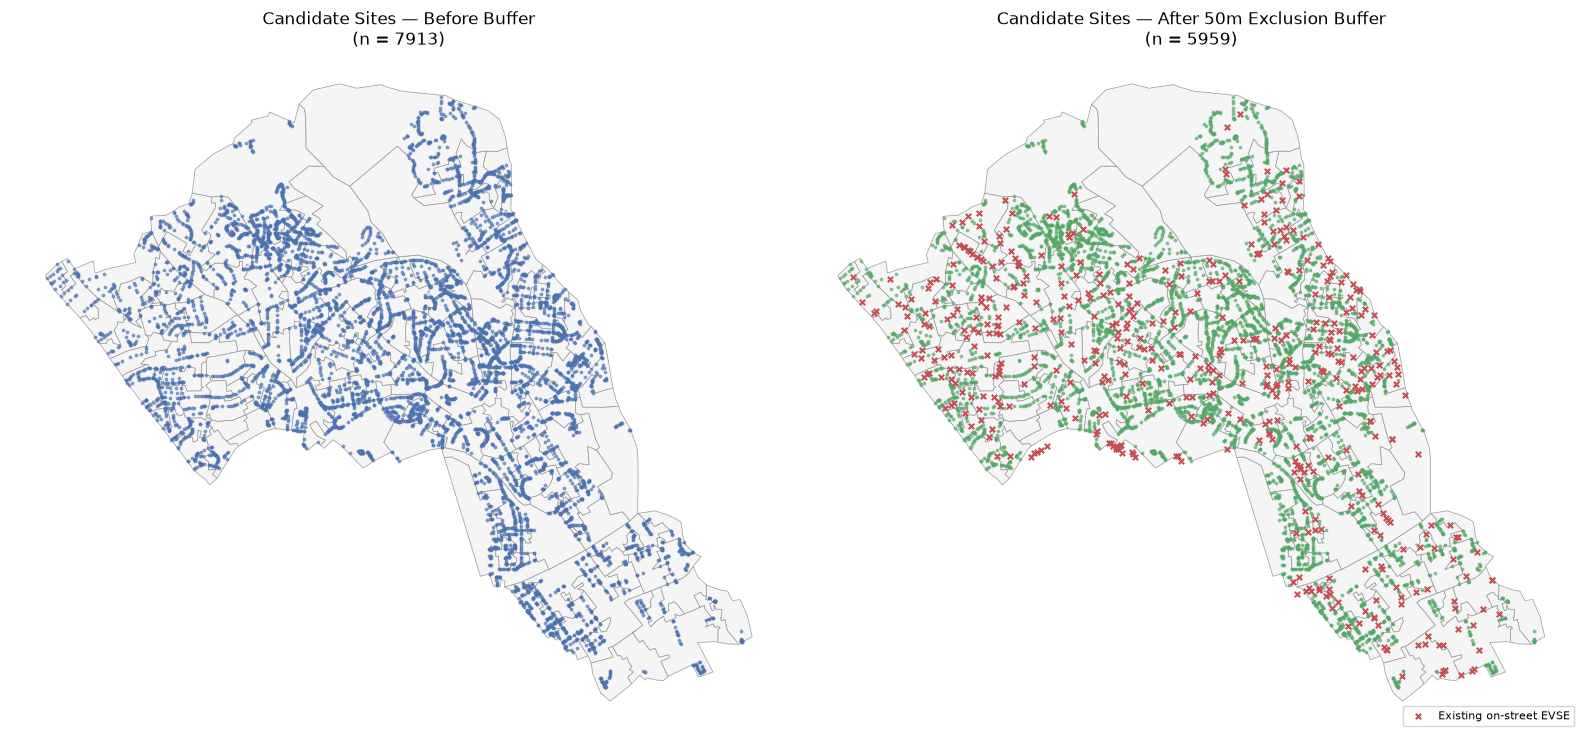

Saved: fig_candidate_sites_before_after_buffer.png


In [51]:
figures_dir = os.path.join(BASE, "06_outputs/toy model")
os.makedirs(figures_dir, exist_ok=True)
print("Figures will be saved to:", figures_dir)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

camden_boundary.plot(ax=axes[0], color="#f5f5f5", edgecolor="#999999", linewidth=0.5)
candidates_gdf.plot(ax=axes[0], color="#4C72B0", markersize=3, alpha=0.6)
axes[0].set_title(f"Candidate Sites — Before Buffer\n(n = {len(candidates_gdf)})")
axes[0].axis("off")

camden_boundary.plot(ax=axes[1], color="#f5f5f5", edgecolor="#999999", linewidth=0.5)
candidates_final.plot(ax=axes[1], color="#55A868", markersize=3, alpha=0.6)
osev_camden_gdf.plot(ax=axes[1], color="#C44E52", markersize=15, marker="x", label="Existing on-street EVSE")
axes[1].set_title(f"Candidate Sites — After 50m Exclusion Buffer\n(n = {len(candidates_final)})")
axes[1].axis("off")
axes[1].legend(loc="lower right", fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(figures_dir, "fig_candidate_sites_before_after_buffer.png"), dpi=300, bbox_inches="tight")
plt.show()
print("Saved: fig_candidate_sites_before_after_buffer.png")

### save candidate sites for p-median

In [52]:
output_path = os.path.join(BASE, "05_processed/camden_candidate_sites.csv")
candidates_export = candidates_final.copy()
candidates_export["x"] = candidates_export.geometry.x
candidates_export["y"] = candidates_export.geometry.y
candidates_export.drop(columns="geometry").to_csv(output_path, index=False)
print("Saved to:", output_path)
print("Shape:", candidates_export.shape)

Saved to: /Users/alexia/Documents/CASA/Dissertation/05_processed/camden_candidate_sites.csv
Shape: (5959, 6)


### Setup — LSOA demand nodes and α=0/0.3 demand weights

### calculate Camden LSOA centroid + filter demand

In [53]:
import numpy as np

# Demand nodes: Camden LSOA centroids (proposal: "the centroid of LSOA i")
camden_centroids = camden_boundary[["lsoa_code", "geometry"]].copy()
camden_centroids["geometry"] = camden_centroids.geometry.centroid
camden_centroids = camden_centroids.rename(columns={"geometry": "centroid"})

# Pull Scenario A (α=0) and Scenario C (α=0.3) demand weights for Camden's 130 LSOAs
demand_london = pd.read_csv(os.path.join(BASE, "05_processed/demand_london.csv"))
camden_demand = camden_centroids.merge(
    demand_london[["lsoa_code", "D_A", "D_C"]], on="lsoa_code", how="left"
)

missing = camden_demand[["D_A", "D_C"]].isna().any(axis=1).sum()
print(f"Camden LSOAs: {len(camden_demand)}, missing demand values: {missing}")
camden_demand.head(3)

Camden LSOAs: 130, missing demand values: 0


,lsoa_code,centroid,D_A,D_C
0,E01000842,POINT (527141.284 184691.731),150.536,153.832738
1,E01000843,POINT (527542.723 184755.105),128.464,137.829026
2,E01000844,POINT (526923.643 184505.261),163.184,167.345192


### Build distance matrix (LSOA centroid → candidate site, Euclidean, EPSG:27700)

### distance matrix

In [54]:
# No k-nearest pruning needed at Camden scale (130 LSOAs × 5,959 sites ≈ 774,670 pairs,
# well within MILP tractability — pruning is reserved for the Greater London scale model)
I = camden_demand["lsoa_code"].tolist()          # demand node IDs
J = candidates_final.index.tolist()               # candidate site IDs (use row index as site ID)

I_coords = np.array([(pt.x, pt.y) for pt in camden_demand["centroid"]])
J_coords = np.array([(pt.x, pt.y) for pt in candidates_final.geometry])

# Pairwise Euclidean distance matrix, shape (|I|, |J|), in metres (EPSG:27700 is in metres)
dist_matrix = np.sqrt(
    ((I_coords[:, None, :] - J_coords[None, :, :]) ** 2).sum(axis=2)
)

print("Distance matrix shape:", dist_matrix.shape)
print(f"Distance range: {dist_matrix.min():.1f}m – {dist_matrix.max():.1f}m")
print(f"Mean distance: {dist_matrix.mean():.1f}m")

Distance matrix shape: (130, 5959)
Distance range: 3.5m – 8187.8m
Mean distance: 2576.4m


### Build p-median MILP (PuLP/CBC) — Scenario-agnostic model builder

In [55]:
import pulp

def build_p_median_model(demand_weights, dist_matrix, p, model_name="p_median"):
    """
    Build a p-median MILP following proposal Section 5.4.

    demand_weights : array-like, length |I|, the Dᵢ value for each demand node
    dist_matrix    : array (|I|, |J|), dᵢⱼ — Euclidean distance, demand node i to candidate site j
    p              : int, number of sites to open

    Constraints (proposal C1–C4; C5 service-radius constraint is excluded here —
    proposal designates it a Phase 2 sensitivity test, not part of the base toy model run)
    C1: yᵢⱼ ≤ xⱼ            — demand only assigned to open sites
    C2: Σⱼ yᵢⱼ = 1           — each LSOA assigned to exactly one site
    C3: Σⱼ xⱼ = p            — exactly p sites opened
    C4: xⱼ, yᵢⱼ ∈ {0,1}      — binary integrality
    """
    n_I, n_J = dist_matrix.shape
    assert len(demand_weights) == n_I

    prob = pulp.LpProblem(model_name, pulp.LpMinimize)

    # Decision variables
    x = pulp.LpVariable.dicts("x", range(n_J), cat="Binary")
    y = pulp.LpVariable.dicts("y", [(i, j) for i in range(n_I) for j in range(n_J)], cat="Binary")

    # Objective: minimise total demand-weighted distance — min Σᵢ Σⱼ Dᵢ · dᵢⱼ · yᵢⱼ
    prob += pulp.lpSum(
        demand_weights[i] * dist_matrix[i][j] * y[(i, j)]
        for i in range(n_I) for j in range(n_J)
    )

    # C2: each demand node assigned to exactly one site
    for i in range(n_I):
        prob += pulp.lpSum(y[(i, j)] for j in range(n_J)) == 1

    # C1: demand assigned only to open sites
    for i in range(n_I):
        for j in range(n_J):
            prob += y[(i, j)] <= x[j]

    # C3: exactly p sites opened
    prob += pulp.lpSum(x[j] for j in range(n_J)) == p

    return prob, x, y

print("build_p_median_model() defined.")

build_p_median_model() defined.


### Instantiate Scenario A and Scenario C models (p=5)

In [56]:
p = 5

prob_A, x_A, y_A = build_p_median_model(
    demand_weights=camden_demand["D_A"].values, dist_matrix=dist_matrix, p=p, model_name="camden_scenario_A"
)
prob_C, x_C, y_C = build_p_median_model(
    demand_weights=camden_demand["D_C"].values, dist_matrix=dist_matrix, p=p, model_name="camden_scenario_C"
)

print(f"Scenario A: {len(prob_A.variables())} variables, {len(prob_A.constraints)} constraints")
print(f"Scenario C: {len(prob_C.variables())} variables, {len(prob_C.constraints)} constraints")

Scenario A: 780629 variables, 774801 constraints
Scenario C: 780629 variables, 774801 constraints


### Solve both scenarios

In [57]:
solver = pulp.PULP_CBC_CMD(msg=True)

print("=== Solving Scenario A (α=0) ===")
prob_A.solve(solver)
print(f"Status: {pulp.LpStatus[prob_A.status]}")
print(f"Objective (Σ Dᵢ·dᵢⱼ·yᵢⱼ): {pulp.value(prob_A.objective):,.1f}")

print()
print("=== Solving Scenario C (α=0.3) ===")
prob_C.solve(solver)
print(f"Status: {pulp.LpStatus[prob_C.status]}")
print(f"Objective (Σ Dᵢ·dᵢⱼ·yᵢⱼ): {pulp.value(prob_C.objective):,.1f}")

=== Solving Scenario A (α=0) ===
Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/pulp/apis/../solverdir/cbc/osx/i64/cbc /var/folders/ns/mq6gshc5381576s51jjzgybm0000gn/T/99afebda204a4609a4013b8423dd1e8e-pulp.mps -timeMode elapsed -solve -printingOptions all -solution /var/folders/ns/mq6gshc5381576s51jjzgybm0000gn/T/99afebda204a4609a4013b8423dd1e8e-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 774806 COLUMNS
At line 5440704 RHS
At line 6215506 BOUNDS
At line 6996136 ENDATA
Problem MODEL has 774801 rows, 780629 columns and 2329969 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Continuous objective value is 1.59177e+07 - 294.62 seconds
Cgl0004I processed model has 774801 rows, 780629 columns (780629 integer (780629 of which binary)) and 2329969 elements
Cbc0038I Initial state - 0 integers 

### Extract opened sites and assignments

In [58]:
def extract_solution(x_vars, y_vars, n_I, n_J, dist_matrix):
    """Extract opened site indices and, for each demand node, its assigned site and distance."""
    opened_sites = [j for j in range(n_J) if pulp.value(x_vars[j]) > 0.5]

    assigned_site = np.full(n_I, -1, dtype=int)
    assigned_dist = np.full(n_I, np.nan)
    for i in range(n_I):
        for j in opened_sites:
            if pulp.value(y_vars[(i, j)]) > 0.5:
                assigned_site[i] = j
                assigned_dist[i] = dist_matrix[i][j]
                break

    return opened_sites, assigned_site, assigned_dist

opened_A, assigned_site_A, assigned_dist_A = extract_solution(x_A, y_A, len(I), len(J), dist_matrix)
opened_C, assigned_site_C, assigned_dist_C = extract_solution(x_C, y_C, len(I), len(J), dist_matrix)

print(f"Scenario A — sites opened: {opened_A}")
print(f"Scenario C — sites opened: {opened_C}")
print(f"Sites shared between A and C: {set(opened_A) & set(opened_C)}")

Scenario A — sites opened: [496, 3064, 4881, 5862, 5897]
Scenario C — sites opened: [496, 3064, 4881, 5862, 5896]
Sites shared between A and C: {496, 4881, 3064, 5862}


### M1–M4 evaluation metrics

In [59]:
# M1 uses FIXED driving-age population weights (Pᵢ), not the equity-adjusted Dᵢ, so efficiency
# cost is measured on the same basis across scenarios with different α — proposal Section 5.6
census_london_full = pd.read_csv(os.path.join(BASE, "05_processed/census_london_clean.csv"))
imd_london_full    = pd.read_csv(os.path.join(BASE, "05_processed/imd_london_clean.csv"))

camden_eval = camden_demand[["lsoa_code"]].merge(
    census_london_full[["lsoa_code", "driving_age_pop"]], on="lsoa_code", how="left"
).merge(
    imd_london_full[["lsoa_code", "income_decile"]], on="lsoa_code", how="left"
)
Pi = camden_eval["driving_age_pop"].values
income_decile = camden_eval["income_decile"].values

def gini(x):
    x = np.sort(np.asarray(x, dtype=float))
    n = len(x)
    if x.sum() == 0:
        return 0.0
    cum = np.cumsum(x)
    return (2 * np.sum((np.arange(1, n + 1)) * x) - (n + 1) * cum[-1]) / (n * cum[-1])

def compute_metrics(assigned_dist, Pi, income_decile, radius=800):
    covered = (assigned_dist < radius).astype(float)

    M1 = np.sum(Pi * assigned_dist) / np.sum(Pi)
    M2 = np.sum(Pi * covered) / np.sum(Pi)

    cov_d1  = covered[income_decile == 1].mean() if (income_decile == 1).any() else np.nan
    cov_d10 = covered[income_decile == 10].mean() if (income_decile == 10).any() else np.nan
    M3 = cov_d10 / cov_d1 if cov_d1 and cov_d1 > 0 else np.nan

    M4 = gini(covered)

    return {"M1_avg_dist_m": round(M1, 1), "M2_coverage_800m": round(M2, 4),
            "M3_imd_gap": round(M3, 4) if not np.isnan(M3) else None, "M4_gini": round(M4, 4)}

metrics_A = compute_metrics(assigned_dist_A, Pi, income_decile)
metrics_C = compute_metrics(assigned_dist_C, Pi, income_decile)

metrics_table = pd.DataFrame([
    {"Scenario": "A (α=0)",   **metrics_A},
    {"Scenario": "C (α=0.3)", **metrics_C},
])
print(metrics_table.to_string(index=False))

output_path = os.path.join(BASE, "05_processed/camden_toy_model_metrics.csv")
metrics_table.to_csv(output_path, index=False)
print(f"\nSaved to: {output_path}")

 Scenario  M1_avg_dist_m  M2_coverage_800m  M3_imd_gap  M4_gini
  A (α=0)          736.4            0.6060         0.7   0.4000
C (α=0.3)          736.4            0.6153         0.7   0.3923

Saved to: /Users/alexia/Documents/CASA/Dissertation/05_processed/camden_toy_model_metrics.csv


### Fig F2 — Camden basemap, Scenario A vs C site comparison

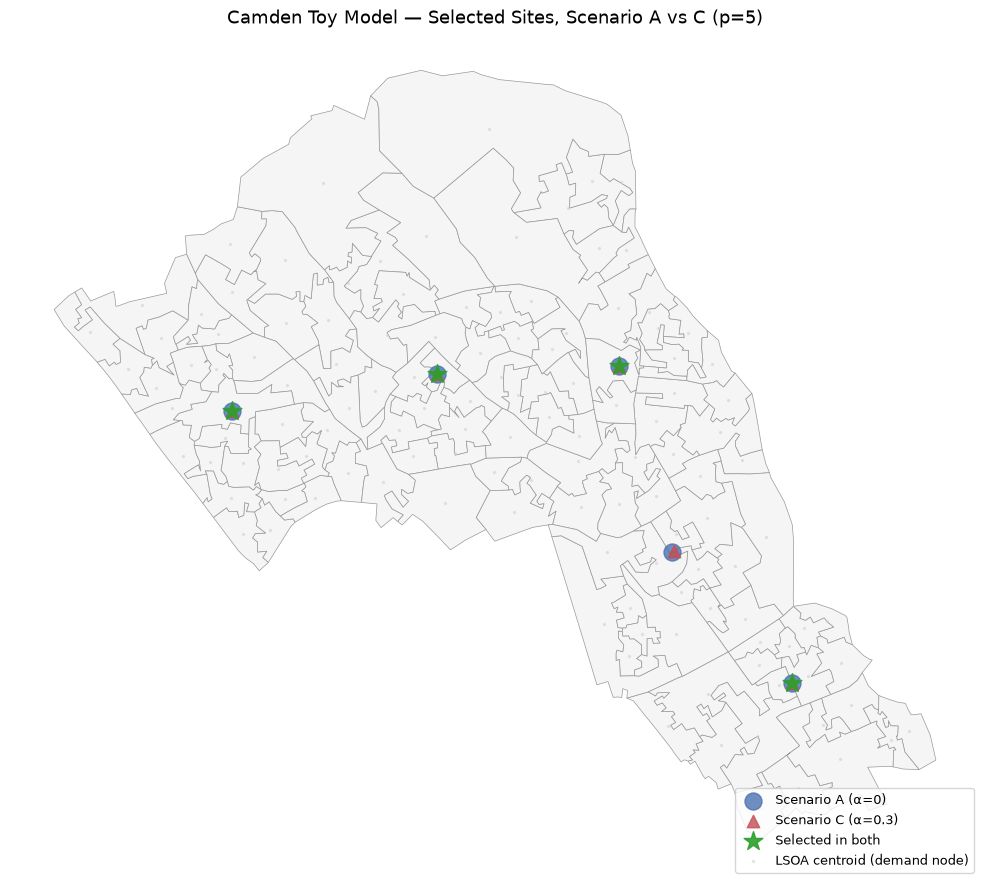

Saved: fig_toy_model_A_vs_C.png


In [60]:
sites_A_gdf = candidates_final.iloc[opened_A].copy()
sites_C_gdf = candidates_final.iloc[opened_C].copy()
shared_idx = list(set(opened_A) & set(opened_C))
shared_gdf = candidates_final.iloc[shared_idx].copy() if shared_idx else None

fig, ax = plt.subplots(figsize=(10, 10))
camden_boundary.plot(ax=ax, color="#f5f5f5", edgecolor="#999999", linewidth=0.5)

sites_A_gdf.plot(ax=ax, color="#4C72B0", markersize=150, marker="o", alpha=0.8, label="Scenario A (α=0)", zorder=3)
sites_C_gdf.plot(ax=ax, color="#C44E52", markersize=80, marker="^", alpha=0.8, label="Scenario C (α=0.3)", zorder=4)
if shared_gdf is not None and len(shared_gdf) > 0:
    shared_gdf.plot(ax=ax, color="#2ca02c", markersize=200, marker="*", alpha=0.9, label="Selected in both", zorder=5)

camden_demand_gdf = gpd.GeoDataFrame(camden_demand, geometry="centroid", crs="EPSG:27700")
camden_demand_gdf.plot(ax=ax, color="lightgrey", markersize=8, marker=".", alpha=0.5, zorder=2, label="LSOA centroid (demand node)")

ax.set_title(f"Camden Toy Model — Selected Sites, Scenario A vs C (p={p})", fontsize=13)
ax.axis("off")
ax.legend(loc="lower right", fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(figures_dir, "fig_toy_model_A_vs_C.png"), dpi=300, bbox_inches="tight")
plt.show()
print("Saved: fig_toy_model_A_vs_C.png")

## Scenario D

In [61]:
camden_demand = camden_demand.merge(demand_london[["lsoa_code", "D_D"]], on="lsoa_code", how="left")
print(camden_demand[["lsoa_code", "D_A", "D_C", "D_D"]].head(3))

   lsoa_code      D_A         D_C         D_D
0  E01000842  150.536  153.832738  156.030564
1  E01000843  128.464  137.829026  144.072376
2  E01000844  163.184  167.345192  170.119320


In [62]:
prob_D, x_D, y_D = build_p_median_model(
    demand_weights=camden_demand["D_D"].values, dist_matrix=dist_matrix, p=p, model_name="camden_scenario_D"
)
print(f"Scenario D: {len(prob_D.variables())} variables, {len(prob_D.constraints)} constraints")

print("=== Solving Scenario D (α=0.5) ===")
prob_D.solve(solver)
print(f"Status: {pulp.LpStatus[prob_D.status]}")
print(f"Objective (Σ Dᵢ·dᵢⱼ·yᵢⱼ): {pulp.value(prob_D.objective):,.1f}")

Scenario D: 780629 variables, 774801 constraints
=== Solving Scenario D (α=0.5) ===
Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/pulp/apis/../solverdir/cbc/osx/i64/cbc /var/folders/ns/mq6gshc5381576s51jjzgybm0000gn/T/1db1483ca3074476bb0bb04ae2adea90-pulp.mps -timeMode elapsed -solve -printingOptions all -solution /var/folders/ns/mq6gshc5381576s51jjzgybm0000gn/T/1db1483ca3074476bb0bb04ae2adea90-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 774806 COLUMNS
At line 5440704 RHS
At line 6215506 BOUNDS
At line 6996136 ENDATA
Problem MODEL has 774801 rows, 780629 columns and 2329969 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Continuous objective value is 1.79551e+07 - 241.59 seconds
Cgl0004I processed model has 774801 rows, 780629 columns (780629 integer (780629 of which binary)) and 23

In [63]:
opened_D, assigned_site_D, assigned_dist_D = extract_solution(x_D, y_D, len(I), len(J), dist_matrix)

print(f"Scenario D — sites opened: {opened_D}")
print(f"Sites shared with A: {set(opened_D) & set(opened_A)}")
print(f"Sites shared with C: {set(opened_D) & set(opened_C)}")

metrics_D = compute_metrics(assigned_dist_D, Pi, income_decile)
metrics_table = pd.concat([metrics_table, pd.DataFrame([{"Scenario": "D (α=0.5)", **metrics_D}])], ignore_index=True)
print(metrics_table.to_string(index=False))

output_path = os.path.join(BASE, "05_processed/camden_toy_model_metrics.csv")
metrics_table.to_csv(output_path, index=False)
print(f"\nSaved to: {output_path}")

Scenario D — sites opened: [496, 3064, 4881, 5862, 5896]
Sites shared with A: {496, 4881, 3064, 5862}
Sites shared with C: {5862, 5896, 496, 4881, 3064}
 Scenario  M1_avg_dist_m  M2_coverage_800m  M3_imd_gap  M4_gini
  A (α=0)          736.4            0.6060         0.7   0.4000
C (α=0.3)          736.4            0.6153         0.7   0.3923
D (α=0.5)          736.4            0.6153         0.7   0.3923

Saved to: /Users/alexia/Documents/CASA/Dissertation/05_processed/camden_toy_model_metrics.csv


### Fig F2 (updated) — A vs C vs D

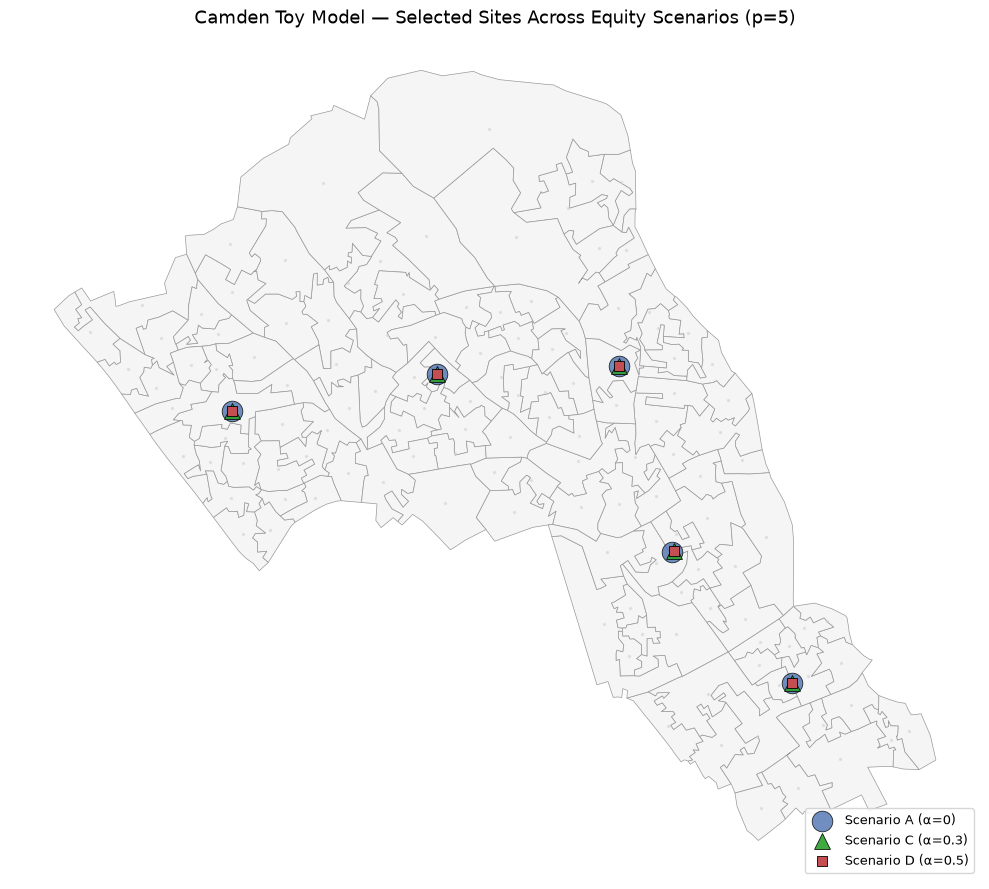

Saved: fig_toy_model_A_vs_C_vs_D.png


In [64]:
sites_A_gdf = candidates_final.iloc[opened_A].copy()
sites_C_gdf = candidates_final.iloc[opened_C].copy()
sites_D_gdf = candidates_final.iloc[opened_D].copy()

fig, ax = plt.subplots(figsize=(10, 10))
camden_boundary.plot(ax=ax, color="#f5f5f5", edgecolor="#999999", linewidth=0.5)

# Different marker shape + decreasing size so overlapping sites (likely, given prior A vs C result)
# remain visible as layered markers rather than fully hiding each other
sites_A_gdf.plot(ax=ax, color="#4C72B0", markersize=220, marker="o", edgecolor="black", linewidth=0.6, alpha=0.8, label="Scenario A (α=0)", zorder=3)
sites_C_gdf.plot(ax=ax, color="#2ca02c", markersize=130, marker="^", edgecolor="black", linewidth=0.6, alpha=0.9, label="Scenario C (α=0.3)", zorder=4)
sites_D_gdf.plot(ax=ax, color="#C44E52", markersize=60, marker="s", edgecolor="black", linewidth=0.6, alpha=1.0, label="Scenario D (α=0.5)", zorder=5)

camden_demand_gdf = gpd.GeoDataFrame(camden_demand, geometry="centroid", crs="EPSG:27700")
camden_demand_gdf.plot(ax=ax, color="lightgrey", markersize=8, marker=".", alpha=0.5, zorder=2)

ax.set_title(f"Camden Toy Model — Selected Sites Across Equity Scenarios (p={p})", fontsize=13)
ax.axis("off")
ax.legend(loc="lower right", fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(figures_dir, "fig_toy_model_A_vs_C_vs_D.png"), dpi=300, bbox_inches="tight")
plt.show()
print("Saved: fig_toy_model_A_vs_C_vs_D.png")

C和D的5个选点完全相同（496、3064、4881、5862、5896），M1-M4四个指标C和D一模一样到小数点后四位。图上看得很清楚，三种marker几乎完全叠在同一个点上。
A→C（α从0到0.3）：5个点里1个变了（5897→5896）
C→D（α从0.3到0.5）：5个点完全不变

quity效应在α还很小的时候就已经"打满"了——大概在0到0.3之间的某个临界值，那个边际位置（第5个名额）的排名发生了一次翻转，翻转之后哪怕继续把α拉到0.5，也没有力气再撼动任何一个选点了。

为什么会这样：α=0.5时multiplier最多是1+0.5×0.998≈1.50，看起来比α=0.3的1.30大不少，但Camden这130个LSOA之间driving_age_pop本身的差距能到4倍以上。换句话说，population差距这个"地基"远比equity multiplier这个"加成"大得多——只要一个LSOA人口够多，哪怕α拉到0.5，加成也补不平这个人口差距，所以前4个稳定占据top-5的LSOA几乎不可能被挤掉，只有那种"原本排名卡在第5名边缘"的LSOA才会因为multiplier的变化被替换，而这种"卡在边缘"的位置在Camden只有一个名额（p=5），一旦被占满，继续加大α也没用了

这个发现其实比proposal里H4假设的还要干脆——H4预测的是"C→D的边际收益比A→C小"（递减），你这个结果是"C→D边际收益直接等于0"（饱和），方向完全一致，只是更极端。这是可以诚实写进toy model小节discussion的内容，不丢人，反而说明你的pipeline对这种细微差异足够敏感，能捕捉到"哪一步开始饱和"这种现象。

In [66]:
pipeline_summary = pd.read_csv(os.path.join(BASE, "05_processed/pipeline_summary.csv"))
pipeline_summary.loc[pipeline_summary["Item"] == "Candidate sites generated (Camden, pre-buffer)", "Count"] = str(7913)
pipeline_summary.loc[pipeline_summary["Item"] == "Candidate sites after 50m exclusion buffer", "Count"] = str(5959)
pipeline_summary.to_csv(os.path.join(BASE, "05_processed/pipeline_summary.csv"), index=False)
print(pipeline_summary.to_string(index=False))

                                          Item  Count
                 LSOAs loaded (Greater London)   4994
   On-street EVSE locations (OpenStreetEV_GLA)  21366
 Session records (join_august2025, post-clean) 215037
                  Unique EVSEs with ≥1 session  10465
        EVSEs matched to LSOA via spatial join  10465
Candidate sites generated (Camden, pre-buffer)   7913
    Candidate sites after 50m exclusion buffer   5959
